Fixed-mixup
====

This notebook presents how to use the cleaned code for Fixed-mixup. See Section 4 of the Image Obfuscation for Privacy-Preserving Machine Learning report for more details.

In [1]:
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

In [2]:
import util
import exp_models
import lambdas

We insert this code snippet to remove pseudorandomness. NN training results may still vary due to CUDA being enabled.

In [3]:
# Reproducibility
SEED = 2019

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

We import our dataset and set our model

In [4]:

trainset, testset = util.get_sets("CIFAR100")
model_getter = exp_models.resnet18_100classes

Files already downloaded and verified
Files already downloaded and verified


We define the dataloaders and take a look at what the dataloader looks like:

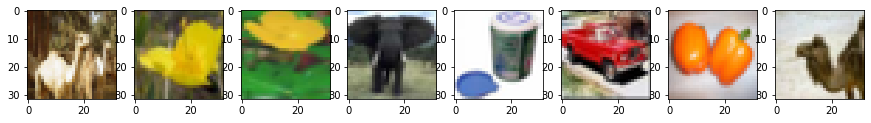

In [5]:
trainloader, N_BATCHES_TRAIN = util.get_loader(trainset, shuffle=True)
testloader, N_BATCHES_TEST = util.get_loader(testset, shuffle=False)
util.show_loader_cf(trainloader)

We load lambdas, in our example we will use the linear lambdas with $N=4$. We will only use the first one to demonstrate the notebook. See an analysis of the lambdas in the report in subsection 4.5.

[0.5        0.33333333 0.16666667 0.        ]
[0.4375 0.3125 0.1875 0.0625]
[0.375      0.29166667 0.20833333 0.125     ]
[0.3125     0.27083333 0.22916667 0.1875    ]


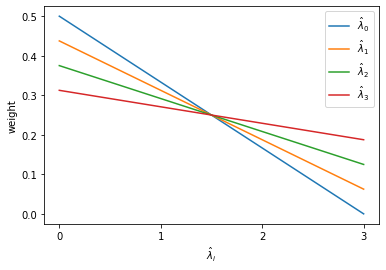

In [6]:
LAMBDAS = lambdas.linear(4, 4)
lambdas.show(LAMBDAS)
# only use one to shorten the run time of this notebook
LAMBDAS = LAMBDAS[:1]

We use *util.perform_experiment* to automate the experiments.

Note: we run this experiment on 5 epochs/100 batches, which will yield poor test accuracy compared to the 100 epochs/500 batches used in the report experiments.

In [7]:

RESULTS_FNAME = "deleteme0"
with open("results/"+RESULTS_FNAME, "w"):pass
test_accs, train_losses, val_losses, images_mx, ys, perms = util.perform_experiment(
    trainloader,
    testloader,
    lambdas=LAMBDAS,
    results_fname=RESULTS_FNAME,
    N_BATCHES_TRAIN=N_BATCHES_TRAIN,
    model_getter=model_getter,
    n_epochs=5,
    n_batches=100
)


Saving results in deleteme0
Trying lambda= [0.5        0.33333333 0.16666667 0.        ]
Performing n-mixup with N-mix: 4
Epoch[1/5]
train loss:4.6883 Epoch[1/5] Batch[0/500]
train loss:4.6012 Epoch[1/5] Batch[50/500]
train loss:4.4957 Epoch[1/5] Batch[100/500]
val loss:4.0829 Epoch[1/5]
val acc:10.0000 Epoch[1/5]
Epoch[2/5]
train loss:4.5170 Epoch[2/5] Batch[0/500]
train loss:4.4207 Epoch[2/5] Batch[50/500]
train loss:4.3549 Epoch[2/5] Batch[100/500]
val loss:4.0487 Epoch[2/5]
val acc:7.0000 Epoch[2/5]
Epoch[3/5]
train loss:4.3122 Epoch[3/5] Batch[0/500]
train loss:4.4215 Epoch[3/5] Batch[50/500]
train loss:4.4332 Epoch[3/5] Batch[100/500]
val loss:3.9441 Epoch[3/5]
val acc:8.0000 Epoch[3/5]
Epoch[4/5]
train loss:4.3627 Epoch[4/5] Batch[0/500]
train loss:4.4277 Epoch[4/5] Batch[50/500]
train loss:4.3435 Epoch[4/5] Batch[100/500]
val loss:3.7327 Epoch[4/5]
val acc:16.0000 Epoch[4/5]
Epoch[5/5]
train loss:4.2012 Epoch[5/5] Batch[0/500]
train loss:4.2723 Epoch[5/5] Batch[50/500]
train lo

We can see what the last batch of samples looked like through *images_mx*:

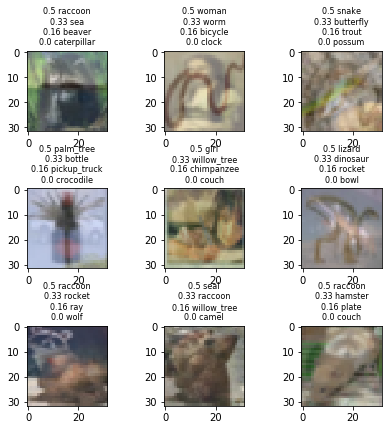

In [8]:

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
plt.tight_layout(pad=2)
for j in range(3):
    for i in range(3):
        util.show_np_arr(images_mx.cpu()[j*3+i], ax=axes[j, i])
        titles = [
            str(LAMBDAS[0][k])[:4] + " " + trainset.classes[ys[k][j*3+i]]
            for k in range(LAMBDAS[0].shape[0])
        ]
        axes[j, i].set_title('\n'.join(titles), fontsize=8, rotation=0)

#### FMNIST

If instead of CIFAR10/CIFAR100 we want to train on FMNIST, we need to change a few things.

In [9]:

trainset, testset = util.get_sets("FashionMNIST")
model_getter = exp_models.CNN # compatible model

We can creater loader and look at the samples with this other function of util:

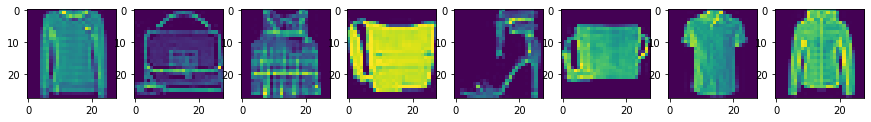

In [10]:
trainloader, N_BATCHES_TRAIN = util.get_loader(trainset, shuffle=True)
testloader, N_BATCHES_TEST = util.get_loader(testset, shuffle=False)
util.show_loader_fm(trainloader)

The rest of the code for training on FashionMNIST would be the same as CIFAR10/CIFAR100